In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Task - 1:

Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

• Use Data Augmentation to increase the number of training image.

• Use deeper model with BN and DropOut layer as presented above.

• Understand the Model Summary and Training Behavior.

In [18]:
import os

train_dir = "/content/drive/MyDrive/AI Sem6/Worksheet5/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in traning folder")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


test_dir = "/content/drive/MyDrive/AI Sem6/Worksheet5/FruitinAmazon/test" # Assuming test directory is 'test' and not 'train'

test_class_names = sorted(os.listdir(test_dir))

if not test_class_names:
    print("No class directories found in traning folder")
else:
    print(f"Found {len(test_class_names)} classes: {test_class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


###Check for Corrupted Images:

In [19]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path) # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found in traning dataset:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in traning dataset.")


No corrupted images found in traning dataset.


In [20]:
test_corrupted_images = []

for class_name in test_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        test_images = os.listdir(class_path) # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in test_images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found in testing dataset:")
    for img in test_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in testing dataset.")


No corrupted images found in testing dataset.


### Count class Balance:

In [21]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [22]:
# Dictionary to store class counts
test_class_counts = {}
for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in test_class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5



Select Random Images for Visualization:

In [23]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

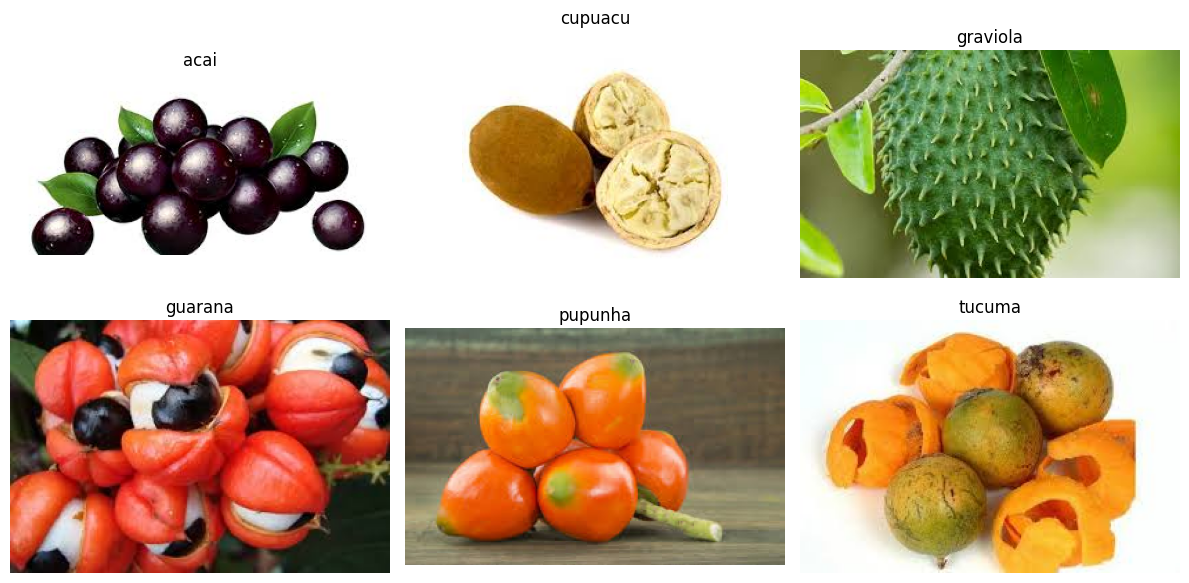

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

Data Generation and Pre - processing:

In [25]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow import keras
image_size = (128, 128)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [27]:
for images, labels in train_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


In [29]:
for images, labels in test_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (30, 128, 128, 3)
Labels shape: (30,)


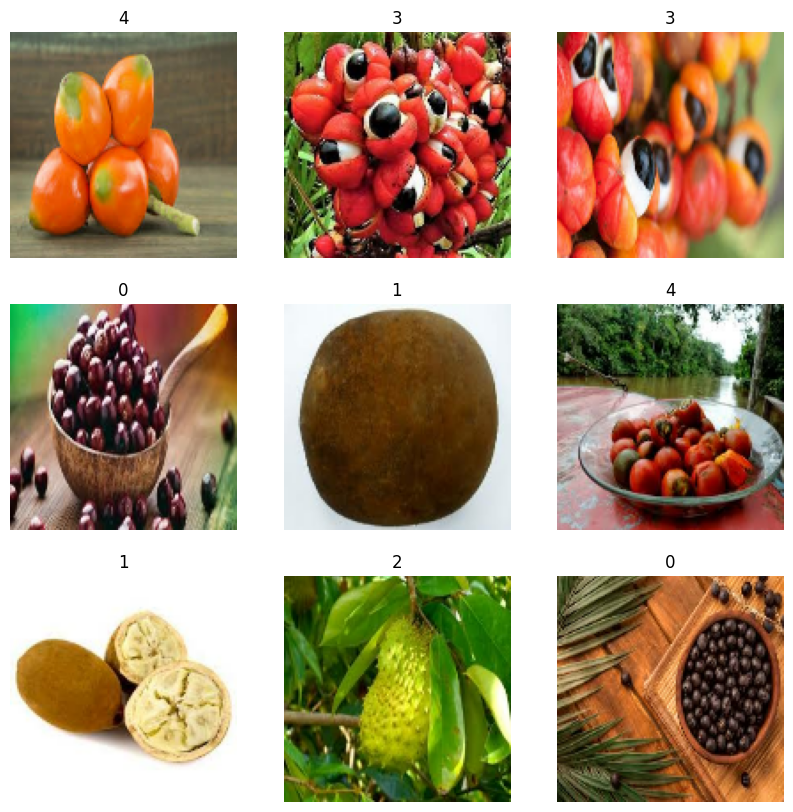

In [30]:
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Takes one batch of images from the dataset (train_ds):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

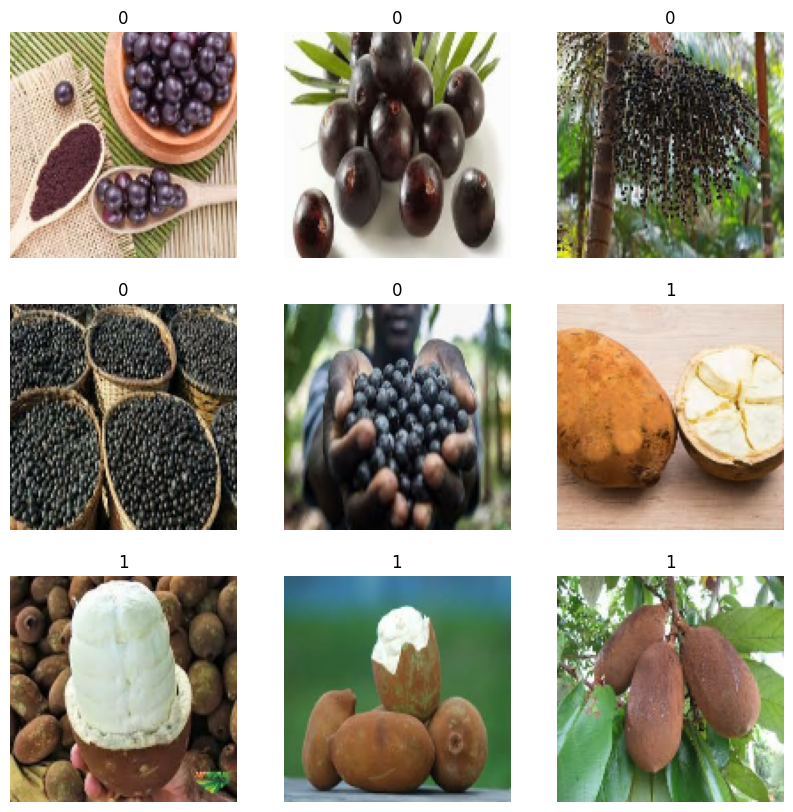

In [31]:
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1): #Takes one batch of images from the dataset (train_ds):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

Data Augumentation function

In [32]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
]
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

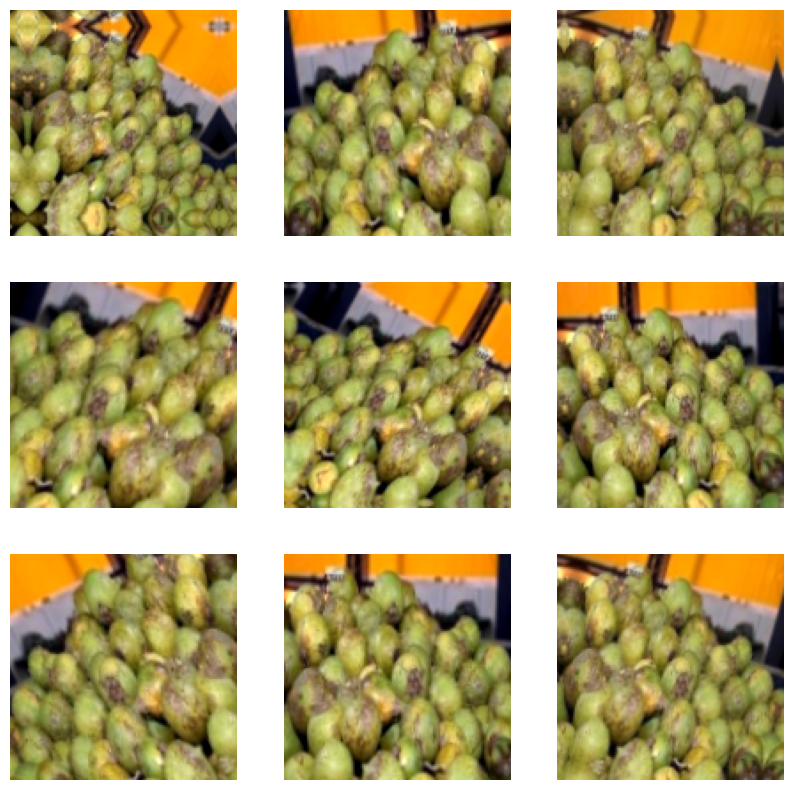

In [33]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

Build Model Architecture

In [34]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

model = Sequential([
# Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),

    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fourth Convolutional Block
    layers.Conv2D(256, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    layers.Flatten(),

    # First Fully Connected Layer
    layers.Dense(512, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Second Fully Connected Layer
    layers.Dense(256, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Third Fully Connected Layer
    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Fourth Fully Connected Layer
    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output Layer with 10 neurons (for classification task with 10 classes)
    layers.Dense(6, activation='softmax')
])

print("Model architecture created successfully!/n")
print("Model Summary:")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model architecture created successfully!/n
Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

Params calculation formula

Conv2D = (kernal_h * kernal_w * channel +1) * output_filters


Dense = (input_features +1 ) * output_units


BatchNorm = 2 * output_units

In [35]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

augmentation_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

model = Sequential([
    augmentation_model,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(6, activation='softmax')
])

print("Model architecture created successfully!")
model.summary()

Model architecture created successfully!


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,390,342 (32.01 MB)

 Trainable params: 8,390,150 (32.01 MB)

 Non-trainable params: 192 (768.00 B)

In [36]:
#compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
#train the model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    batch_size=5,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.1997 - loss: 2.2917
Epoch 1: val_loss improved from None to 9.23464, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 624ms/step - accuracy: 0.2083 - loss: 2.3765 - val_accuracy: 0.0556 - val_loss: 9.2346
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.3241 - loss: 2.0013
Epoch 2: val_loss improved from 9.23464 to 4.28104, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - accuracy: 0.3472 - loss: 1.9144 - val_accuracy: 0.0556 - val_loss: 4.2810
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.3941 - loss: 1.5424
Epoch 3: val_loss improved from 4.28104 to 2.33039, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 524ms/step - accuracy: 0.4167 - loss: 1.5018 - val_accuracy: 0.0556 - val_loss: 2.3304
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.4994 - loss: 1.4025
Epoch 4: val_loss improved from 2.33039 to 1.76386, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - accuracy: 0.5139 - loss: 1.3564 - val_accuracy: 0.2222 - val_loss: 1.7639
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5781 - loss: 1.1521
Epoch 5: val_loss improved from 1.76386 to 1.62347, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 0.5972 - loss: 1.2127 - val_accuracy: 0.3333 - val_loss: 1.5718
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6198 - loss: 1.1362
Epoch 7: val_loss improved from 1.57176 to 1.55164, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 621ms/step - accuracy: 0.6250 - loss: 1.1618 - val_accuracy: 0.4444 - val_loss: 1.5516
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6354 - loss: 0.9960
Epoch 8: val_loss improved from 1.55164 to 1.54161, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 617ms/step - accuracy: 0.6250 - loss: 1.0075 - val_accuracy: 0.4444 - val_loss: 1.5416
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6898 - loss: 0.9543
Epoch 9: val_loss improved from 1.54161 to 1.52900, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6944 - loss: 0.9749 - val_accuracy: 0.3889 - val_loss: 1.5290
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - accuracy: 0.6916 - loss: 0.8056
Epoch 10: val_loss improved from 1.52900 to 1.52111, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6528 - loss: 0.8792 - val_accuracy: 0.3333 - val_loss: 1.5211
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6800 - loss: 0.9930
Epoch 11: val_loss did not improve from 1.52111
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 685ms/step - accuracy: 0.6806 - loss: 1.0014 - val_accuracy: 0.3333 - val_loss: 1.5218
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7361 - loss: 0.8696
Epoch 12: val_loss did not improve from 1.52111
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 446ms/step - accuracy: 0.7083 - loss: 0.8940 - val_accuracy: 0.2778 - val_loss: 1.5247
Epoch 13/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7130 - loss: 0.7727
Epoch 13: val_loss did not improve from 1.52111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.7639 - loss: 0.7269 - val_accuracy: 0.3333 - val_loss: 1.5262
Epoch 14/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7506 - loss: 0.7468
Epoch 14:

In [38]:
#evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.2667 - loss: 1.6326
Test Loss: 1.6326
Test Accuracy: 0.2667 (26.67%)


In [39]:
#save the model
model.save('trained_fruit_model.keras')
loaded_model = keras.models.load_model('trained_fruit_model.keras')
print("Loaded successfully!")

Loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


###Image classification via fine-tuning with VGG16


Load the Pre - trained Model:

In [40]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


###Freeze the Layers:

In this step, you freeze the layers of the pre-trained model, so their weights do not get updated during training. This helps in preserving the knowledge from the pre-training on ImageNet.

This loop goes through each layer in the base model and sets layer.trainable = False, which ensures that these layers will not be updated during backpropagation.

In [42]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

Custom Layers:

In [45]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(6, activation='softmax')(x) # Output layer for 6 classes (with softmax for multi-class classification)


###Create the Final Model

In [46]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)


Compile and Fit the model.

In [47]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    batch_size=5,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2344 - loss: 8.0270
Epoch 1: val_loss improved from None to 11.81470, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.2500 - loss: 8.5105 - val_accuracy: 0.3333 - val_loss: 11.8147
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8304 - loss: 6.0098
Epoch 2: val_loss improved from 11.81470 to 10.34903, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8194 - loss: 5.5907 - val_accuracy: 0.3333 - val_loss: 10.3490
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8895 - loss: 0.7054
Epoch 3: val_loss improved from 10.34903 to 8.69439, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.9028 - loss: 0.5812 - val_accuracy: 0.4444 - val_loss: 8.6944
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9398 - loss: 0.7075
Epoch 4: val_loss did not improve from 8.69439
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9444 - loss: 0.5598 - val_accuracy: 0.3889 - val_loss: 12.0435
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8860 - loss: 0.5765
Epoch 5: val_loss did not improve from 8.69439
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8611 - loss: 0.7021 - val_accuracy: 0.3889 - val_loss: 10.5298
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0015
Epoch 6: val_loss did not improve from 8.69439
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.2778 - val_loss: 11.0556
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9751 - loss: 0.0522
Epoch 7: val_loss did not impro


Epoch 11: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 1.0000 - loss: 3.8641e-06 - val_accuracy: 0.5000 - val_loss: 8.3649
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 2.6180e-05
Epoch 12: val_loss improved from 8.36491 to 8.06458, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 1.0000 - loss: 3.6947e-05 - val_accuracy: 0.5556 - val_loss: 8.0646
Epoch 13/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 2.5619e-04
Epoch 13: val_loss improved from 8.06458 to 8.03917, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 1.0000 - loss: 3.6168e-04 - val_accuracy: 0.5000 - val_loss: 8.0392
Epoch 14/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0010    
Epoch 14: val_loss did not improve from 8.03917
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.5000 - val_loss: 8.1084
Epoch 15/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 9.1819e-04
Epoch 15: val_loss did not improve from 8.03917
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.5000 - val_loss: 8.2704
Epoch 16/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 4.3985e-04
Epoch 16: val_loss did not improve from 8.03917
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 1.0000 - loss: 5.1102e-04 - val_accuracy: 0.5000 - val_loss: 8.4353
Epoch 17/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 9.0147e-04
Ep